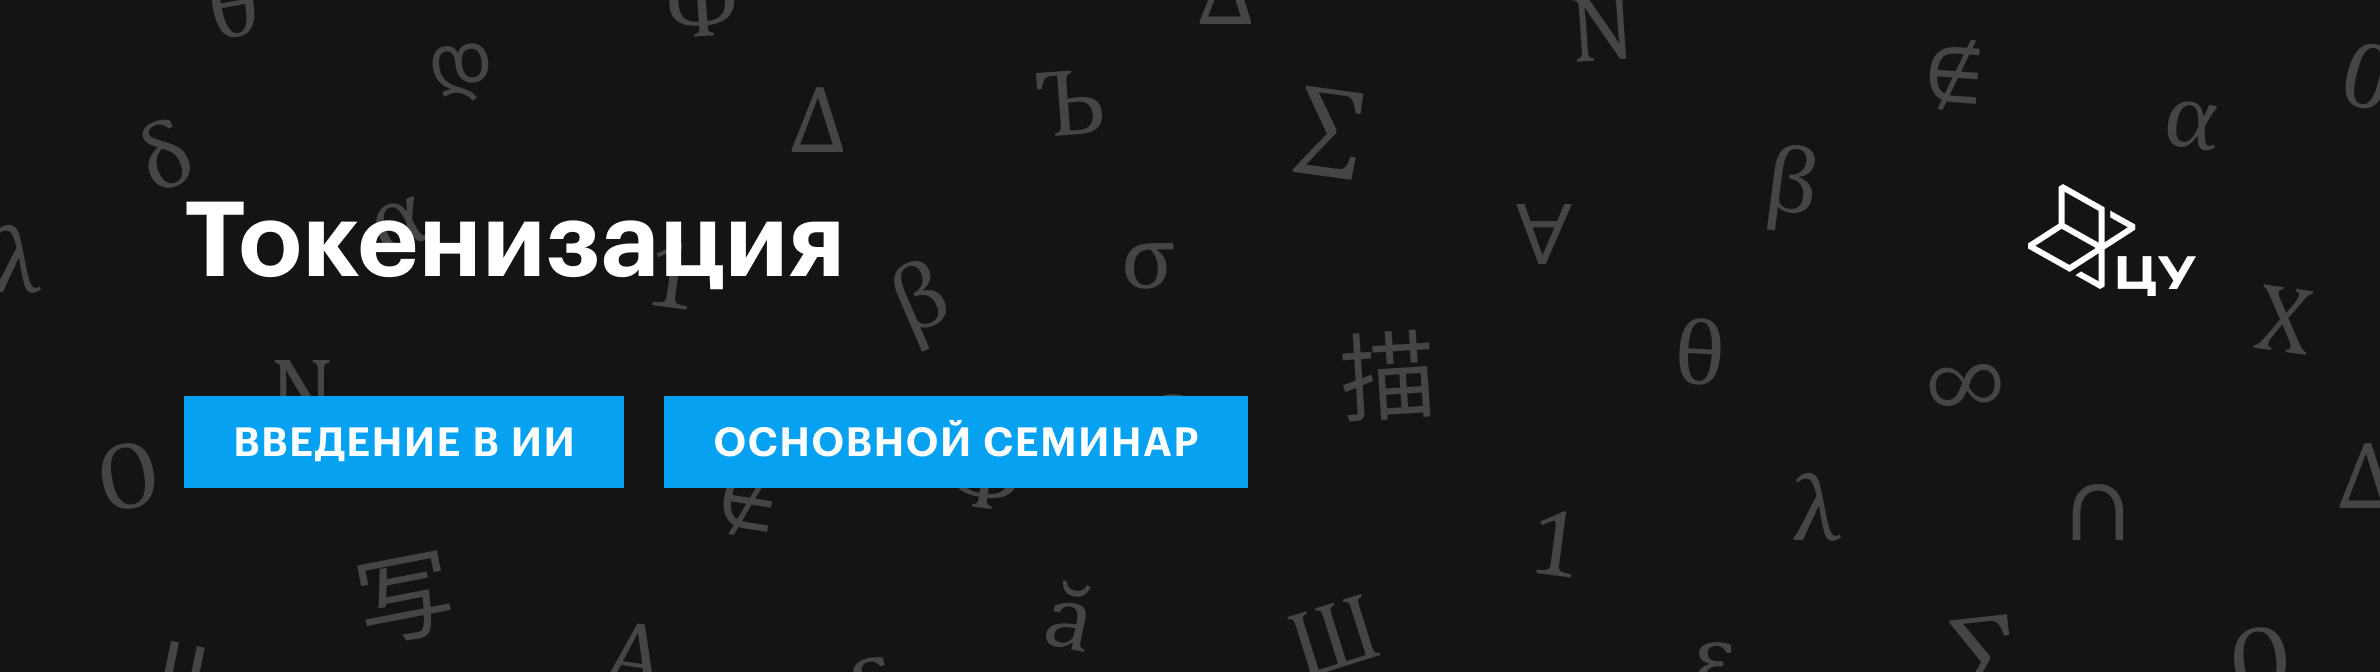

# Семинар по теме «Токенизация»

Сегодня ты познакомишься с примитивной языковой моделью для генерации имён. Она создаёт слова, похожие на имена, и может пригодиться, чтобы давать их детям или домашним животным.

Из этого семинара ты узнаешь:
* что такое n-граммная языковая модель;  
* как создать простую биграмную вероятностную генеративную модель;
* как аппроксимировать биграмную модель с помощью нейросети.

## Языковая модель по n-граммам

> **Языковая модель** — это вероятностная модель, которая оценивает правдоподобие текста — совместную правдоподобность каждого токена $w_t$ в тексте X: $$P(X) = P(w_1, \dots, w_T).$$




Чтобы вычислить правдоподобие текста, используют правило цепочки:
$$P(w_1, \dots, w_T) = P(w_1)P(w_2 \mid w_1)\dots P(w_T \mid w_1, \dots, w_{T-1}).$$

Следуя этому правилу, модель пишет текст последовательно.
1. Генерирует 1-е слово.
2. Если известно 1-е слово, генерирует 2-е слово. И так далее.

При таком подходе возникает проблема для длинных текстов. $n$-ое слово зависит от $n-1$ слов — это делает правдоподобие невычислимым при росте последовательности. Самый простой способ справиться с такой зависимостью — это ограничить число прошлых рассматриваемых слов с помощью $n$-граммной языковой модели, где $n$ — гиперпараметр:

$$P(w_t \mid w_1, \dots, w_{t - 1}) = P(w_t \mid w_{t - n + 1}, \dots, w_{t - 1}).$$

Например, если модель называется три-граммной, то предсказывает третье слово по двум прошлым словам. В нашем же случае каждый текст состоит всего из одного слова — имени. Поэтому будем строить модель на буквах:

$$
    P(w_1, \dots, w_n) = \prod_t P(w_t \mid w_{t - n + 1}, \dots, w_{t - 1}).
$$

**Вопрос.** Откуда брать вероятности букв?

## Подготовка

Итак, мы хотим генерировать правдоподобные имена. Для этого будем обучать модель на российских именах — используем датасет с Гугл-диска.

In [ ]:
# Загружаем датасет. Две ссылки, потому что там мужские и женские имена
!gdown 12HpgM5c2W5jgG8cwbSZTlLSfbo_cpTJL
!gdown 1GAPiDQCKoqNBD0gG01gF-s5glHL3rKuq

# Считываем имена
names = open('russian_female_names.txt', 'r').read().splitlines()
names.extend(open('russian_male_names.txt', 'r').read().splitlines())

# Женские имена; мужские имена; всего имён
names[:10], names[-10:], len(names),

Downloading...
From: https://drive.google.com/uc?id=12HpgM5c2W5jgG8cwbSZTlLSfbo_cpTJL
To: /content/russian_female_names.txt
100% 19.0k/19.0k [00:00<00:00, 37.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GAPiDQCKoqNBD0gG01gF-s5glHL3rKuq
To: /content/russian_male_names.txt
100% 42.1k/42.1k [00:00<00:00, 44.3MB/s]


(['елена',
  'татьяна',
  'наталья',
  'ольга',
  'мария',
  'анна',
  'ирина',
  'светлана',
  'валентина',
  'людмила'],
 ['микаил',
  'нима',
  'арис',
  'лутфирахман',
  'агли',
  'шайхелислам',
  'наири',
  'анантолий',
  'баки',
  'ахметвали'],
 4530)

In [ ]:
# В датасете есть ошибки. В одном имени заменили русскую «c» на английскую «c». В трёх других «н» заменена на «h». Удалим их
for n in ['cергей', 'hаталья', 'hадежда', 'hиколай']:
  names.remove(n)

**Вопрос.** Каждое имя — это набор букв. Но достаточно ли этой информации для модели? Возможно, есть какие-то «скрытые» символы, которые будут подсказывать ей, на каком этапе генерации она находится?

### Задание 1

Мы будем строить языковую модель по биграммам. Для этого нужно учесть все пары соседних токенов.

1. Разбей каждое имя на токены (буквы). Не забудь добавить в начало и конец служебные токены `'\<S>'` и `'\<E>'`.
2. Посчитай частотность каждой пары токенов. Именно от частоты будут зависеть вероятности для правдоподобия.

In [ ]:
b = {}
for name in names:
  chs = # Разбей имя на символы и добавь служебные токены
  for # Проитерируйся по всем парам символов:
    bigram = (ch1, ch2)
    b[bigram] = # Сделай +1 к счётчику

In [ ]:
# Посмотрим на самые частотные токены
sorted(b.items(), key = lambda kv: -kv[1])

Для удобства визуализируем полученные результаты — нарисуем heatmap встречаемости пар токенов.

Имен с «ъ» и «щ» в датасете нет. Поэтому, на heatmap у нас будет:
*   31 буква;
*   2 служебных токена;
*   дефис — для двойных имен из датасета.

Всего понадобятся 34 ячейки по горизонтали и вертикали.

In [ ]:
# Сначала посчитаем количество уникальных токенов и занумеруем их в правильном порядке
chars = sorted(list(set(''.join(names)))) # Уникальные буквы в отсортированном порядке
itos = {i: s for i,s in enumerate(chars)} # Индексируем токены

# Добавиляем служебные токены
itos[len(itos)] = '<S>'
itos[len(itos)] = '<E>'

# Обратная индексация
stoi = {s: i for i, s in itos.items()}

In [ ]:
itos, stoi

In [ ]:
# Воспользуемся pytorch вместо numpy, чтобы потихоньку учить его функционал
import torch

# Создаем матрицу нулей, чтобы записывать туда количества. 1-ая размерность 33, так как последовательность не может начинаться с <E>
N = torch.zeros((33, 34), dtype=torch.int32)

# Записываем в нее количества
for pair in b.keys():
  N[stoi[pair[0]], stoi[pair[1]]] = b[pair]

In [ ]:
import matplotlib.pyplot as plt

# Настройки отображения
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')

# Итерируемся по каждой ячейке и выводим ее значения
for i in range(33):
    for j in range(34):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, b.get((itos[i], itos[j]), 0), ha="center", va="top", color='gray')
plt.axis('off');

**Проанализируем heatmap.** На ней можно увидеть очевидное:
1. Много имен начинаются и/или заканчиваются на «a».
2. Часто встречаются сочетания: «ла», «ма», «ра», «на», и так далее.

Но все это — количества встречаемости пар токенов. А для работы языковой модели нужны вероятности.



**Вопрос.** Как получить вероятности? Наша модель биграммная — по одному прошлому токену мы предсказываем следующий. Поэтому, нам нужна вероятность будующего токена при условии одного прошлого.

### Задание 2

На основе ответа на вопрос выше получи матрицу совместной вероятности двух токенов.

Учти, что наша матрица размером $n$х$n$. Может случиться так, что данные неправильно расширяться (заброадкастятся), а ты даже не заметишь этого — подумай, как это учесть.

In [ ]:
P = # Напиши код здесь

In [ ]:
P

In [ ]:
# Проверим, что мы получили матрицу вероятностей. Для этого просуммируем по строкам
P.sum(1)

Приступим к генерации некоторой категориальной величины с вероятностью из заданного распределения. Для этого используем метод `torch.multinomial`, который возвращает дискретную (категориальную) величину с заданными вероятностями.

Чтобы разобраться в устройстве `torch.multinomial` — нужно изучить [документацию](https://docs.pytorch.org/docs/stable/generated/torch.multinomial.html).

### Задание 3

Сгенерируй:

- следующую букву при условии, что мы подали на вход букву `a`;
- вектор букв, следующих за `a`.



In [ ]:
# Генерируем индекс буквы, которая идёт за буквой «а»
ix = torch.multinomial(# Напиши код здесь)
# По нашему словарю восстанавливаем букву из индекса
itos# Напиши код здесь

In [ ]:
# Можем генерировать сразу несколько вариантов за раз, следующих за буквой «а»
res = torch.multinomial(# Напиши код здесь) # replacement=True значит, что можно повторно генерировать одну и ту же букву
# Преобразуем всё к буквам из индексов
[# Напиши код здесь]

### Задание 4

Напиши генератор имён по шагам.
1. Для текущего токена из таблицы вероятностей получи распределение вероятностей для следующего токена.
2. Предскажи индекс следующего токена.
3. Если это не конец последовательности — добавь в список для букв имени, иначе — останови генерацию.

In [ ]:
# Генератор случайных чисел. Для детерминированной генерации задаём ему seed
g = torch.Generator().manual_seed(123)


# Основная функция для генерации
def generate_name_P(generator):
  out = [] # Контейнер, куда складываем сгенерированные буквы
  ix = # Напиши код здесь # Начинаем генерацию с токена «начало последовательности»
  while True:
    p = # Напиши код здесь # Получаем распределение вероятностей для текущей буквы
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # Генерируем индекс следующей буквы
    if ix == # Напиши код здесь: # Если предсказали «конец последовательности», останавливаемся
      break
    out.append(itos[ix])
  return ''.join(out)

Проверим работоспособность генератора имен:

In [ ]:
# Количество имен
n_names = 10

# Запустим полученную функцию
for _ in range(n_names):
  print(generate_name_P(g))

**Проанализируем результат.** Модель далека от идеальной. Всё потому, что мы предсказываем следующую букву при условии всего лишь одной прошлой. В такой ситуации нередки случаи, когда предсказывается «конец последовательности» сразу после 1-й буквы. Чтобы решить эту проблему, можно усложнить модель — учитывать 2, 3, 4 и следующих букв перед текущей.

Однако, на текущий момент такое качество нас устраивает. Ведь цель семинара — показать работоспособность простейшей модели, а не поcтроить высокоточную модель.

## Правдоподобие

Вернёмся к правдоподобию, которое мы определили в начале семинара.

>**Правдоподобие** — это обобщение многих функций потерь. То есть дифференцируемая функция, которую мы можем оптимизировать.

Вспомним формулу правдоподобия:
$$
    P(w_1, \dots, w_n) = \prod_t P(w_t \mid w_{t - n + 1}, \dots, w_{t - 1}).
$$

Есть и более удобная версия формулы — с расчётом логарифма правдоподобия, чтобы произведения стали суммой:
$$
    \log(P(w_1, \dots, w_n)) = \sum_t \log(P(w_t \mid w_{t - n + 1}, \dots, w_{t - 1})).
$$

Попробуем написать примитивную нейросеть, задача которой — аппроксимация таблицы вероятностей, которую мы посчитали вручную.

В теории такая таблица совместной встречаемости  может быть посчитана всегда и для абсолютно любой задачи. Но на практике таблица будет невероятно большой — поэтому существуют нейросети, позволяющие её аппроксимировать.

In [ ]:
# Для примера вычисления посчитаем все правдоподобия нашего датасета
log_likelihood = 0.0
n = 0

for name in names: # Итерируемся по всему датасету
  chs = ['<S>'] + list(name) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]): # Итерируемся по всем парам токенов
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2] # Получаем вероятности для выбранной пары токенов
    logprob = torch.log(prob) # Логарифмируем
    log_likelihood += logprob
    n += 1

print(f'{log_likelihood=}')
nll = -log_likelihood # Обычно оптимизация функций потерь ведётся на минимум, но логарифм правдоподобия — функция отрицательная, поэтому её умножают на -1 и получают nll — negative log likelihood
print(f'{nll=}')
print(f'{nll/n}')# Среднее значение nll на каждый токен

## Нейросеть

Чтобы обучать нейросеть, нам нужен датасет. Мы не будем определять его как torch.Dataset — в этом нет необходимости из-за простоты модели.

Как и любой датасет для обучения нейросети, он будет иметь формат:

$$Входные~данные → Ответ$$

**Вопрос.**
Что в данном случае входные данные, а что — ответ?

In [ ]:
# Создаём датасет
xs, ys = [], []

for name in names:
  chs = ['<S>'] + list(name) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
xs, ys

#### Подача входных данных

Как тебе известно, алгоритмы машинного обучения на вход принимают только числа. А у нас пока лишь буквы, которые нужно превратить в подходящий формат.

На вход можно подать  индексы, но это плохая идея — они не передают смысл и сходство между словами.

Поэтому нужно каким-то образом получить эмбеддинги. Самый простой способ — использовать OHE-эмбеддинги, которые ты уже знаешь по первому блоку курса.

Для создания OHE в `torch` есть удобный функционал.

In [ ]:
# Сделаем OHE-эмбеддинги для датасета
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=34).float()
# Посмотрим, как выглядят эмбеддинги
xenc[:5]

In [ ]:
# Для удобства восприятия можно нарисовать
plt.imshow(xenc[:5])
plt.show()

С входными данными определились. Далее нужно понять, какого вида будет нейросеть. При условии, что в нашем случае достаточно одного линейного блока.



**Вопросы.**
1. Какой размерности будет блок нейросети и почему?
2. Какую мы решаем задачу по постановке?

### Задание 5

Реализуй получение вероятностей из нейросети.
1. Перемножь вход с линейным слоем — это предсказания нашей нейросети.
2. Получи через softmax распределение вероятностей из выходов нейросети.

In [ ]:
# Как будто бы это веса нашей нейросети
W = torch.randn((34, 34))

# Запишем сразу всё в функцию
def get_probs_NN(W):
  # Предсказания нейросети
  logits = # Напиши код здесь
  # Считаем softmax
  counts = # Напиши код здесь
  return # Напиши код здесь

In [ ]:
# Проверим работоспособность
get_probs_NN(xenc, W)

**Переходим к обучению.** Наш датасет маленький и простой, поэтому для него не нужны:
* DataLoader — потому что можно обучаться сразу на всем датасете.
* Оптимизатор — вместо него сами напишем примитивный градиентный спуск.

### Задание 6


Обучи модель. Для этого реализуй:
- прямой проход по сети;
- функцию потерь.

In [ ]:
# Инициализируем сеть
g = torch.Generator().manual_seed(123) # Тоже хотим избавиться от случайности
W = torch.randn((34, 34), generator=g, requires_grad=True)

# Градиентный спуск
for k in range(25):

  # Прямой проход
  probs = # Напиши код здесь
  loss = # Напиши код здесь # Считаем функцию потерь: выбираем нужные индексы из полученной вероятности, логарифмируем, усредняем и берём с минусом
  print(loss.item())

  # Обратный проход
  W.grad = None # Обнуляем градиент
  loss.backward()

  # Обновлеяем веса
  W.data += -100 * W.grad # Шаг градиентного спуска

Наша модель действительно обучается.

Модель обучена — можно генерировать имена. Порядок действий аналогичен шагам генерации по таблице.

In [ ]:
# Фиксируем случайные числа
g = torch.Generator().manual_seed(123)

# Основная функция для генерации
def generate_name_NN(W, generator):
  out = [] # Контейнер, куда складываем сгенерированные буквы
  ix = 32 # Начинаем генерацию с токена "начало последовательности"
  while True:
    data = F.one_hot(torch.tensor([ix]), num_classes=34).float()
    p = get_probs_NN(data, W) # Получаем распределение вероятностей для текущей буквы
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # Генерируем индекс следующей буквы
    if ix == 33: #Если предсказали "конец последовательности", останавливаемся
      break
    out.append(itos[ix])
  return ''.join(out)

# Запустим полученную функцию
for _ in range(n_names):
  print(generate_name_NN(W, g))

**Проанализируем результат.** Генерация лучше не стала. Все потому, что модель мы не усложняли, а получили результат другим подходом — через оптимизацию правдоподобия.